<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

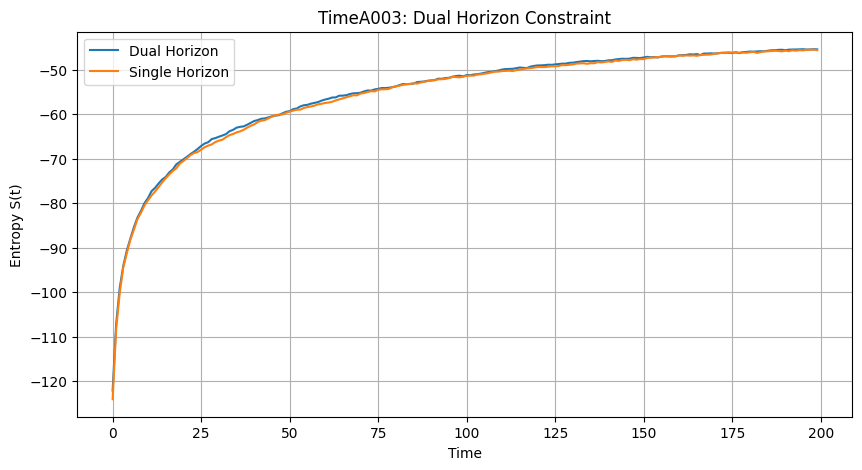

Dual Horizon Metrics:
Entropy Slope: 0.1713
Memory Retention: 0.9970
Irreversibility Index: 80.2214

Single Horizon Metrics:
Entropy Slope: 0.1743
Memory Retention: 0.9968
Irreversibility Index: 83.2001


In [1]:
# 🌒 TimeA003: The Dual Horizon Constraint
# Simulating entropic asymmetry under mirrored boundary conditions
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT027
# Reproducibility Tag: TimeA003_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength, dual_horizon=False):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    lattice = base + curvature
    if dual_horizon:
        lattice[0, :] = lattice[-1, :]  # mirror top and bottom edges
    return lattice

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Function ---
def evolve_lattice(lattice, xi_locking):
    for _ in range(5):
        lattice += 0.01 * np.random.randn(*lattice.shape)
        if xi_locking:
            lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, dual_horizon=False):
    lattice = initialize_lattice(N, curvature_strength, dual_horizon)
    entropy_series = []
    for t in range(T):
        lattice = evolve_lattice(lattice, xi_locking)
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series)

# --- Run Dual and Single Horizon ---
dual_entropy = run_simulation(N, T, curvature_strength, xi_locking, dual_horizon=True)
single_entropy = run_simulation(N, T, curvature_strength, xi_locking, dual_horizon=False)

# --- Metrics ---
def compute_metrics(entropy_series):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    return slope, memory, irreversibility_index

dual_metrics = compute_metrics(dual_entropy)
single_metrics = compute_metrics(single_entropy)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(dual_entropy, label='Dual Horizon')
plt.plot(single_entropy, label='Single Horizon')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA003: Dual Horizon Constraint')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Dual Horizon Metrics:")
print(f"Entropy Slope: {dual_metrics[0]:.4f}")
print(f"Memory Retention: {dual_metrics[1]:.4f}")
print(f"Irreversibility Index: {dual_metrics[2]:.4f}")

print("\nSingle Horizon Metrics:")
print(f"Entropy Slope: {single_metrics[0]:.4f}")
print(f"Memory Retention: {single_metrics[1]:.4f}")
print(f"Irreversibility Index: {single_metrics[2]:.4f}")
